# Анализ поисковых запросов в Яндекс Картинках

**Задача:** Сравнить поведение пользователей на desktop и touch (мобильных) платформах.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandasql as psql
from datetime import datetime

## 1. Загрузка данных

In [2]:
df = pd.read_csv('data.tsv', sep='\t', header=None,
                      names=['query', 'timestamp', 'platform'],
                      dtype={'query': str})
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')

df.head()

,query,timestamp,platform,datetime
0,малевич картины,1631806465,desktop,2021-09-16 15:34:25
1,психология,1631781583,touch,2021-09-16 08:39:43
2,с днём рождения лена,1631771563,touch,2021-09-16 05:52:43
3,зверополис фильмы,1631787599,touch,2021-09-16 10:19:59
4,алабай собака фото,1631786645,touch,2021-09-16 10:04:05


In [3]:
df.describe()

,timestamp,datetime
count,1.114365e+06,1114365
mean,1.631373e+09,2021-09-11 15:04:29.053179648
min,1.630444e+09,2021-08-31 21:00:00
25%,1.630928e+09,2021-09-06 11:38:58
50%,1.631378e+09,2021-09-11 16:36:45
75%,1.631817e+09,2021-09-16 18:38:05
max,1.632258e+09,2021-09-21 20:59:59
std,5.301253e+05,NaN


In [4]:
df.describe(include='all')

,query,timestamp,platform,datetime
count,1114365,1.114365e+06,1114365,1114365
unique,31955,NaN,2,NaN
top,с днём рождения женщине,NaN,touch,NaN
freq,5404,NaN,726101,NaN
mean,NaN,1.631373e+09,NaN,2021-09-11 15:04:29.053179648
min,NaN,1.630444e+09,NaN,2021-08-31 21:00:00
25%,NaN,1.630928e+09,NaN,2021-09-06 11:38:58
50%,NaN,1.631378e+09,NaN,2021-09-11 16:36:45
75%,NaN,1.631817e+09,NaN,2021-09-16 18:38:05
max,NaN,1.632258e+09,NaN,2021-09-21 20:59:59


In [5]:
df.isna().sum()

query        0
timestamp    0
platform     0
datetime     0
dtype: int64

## 2. Диапазон дат

In [6]:
df['date'] = pd.to_datetime(df['datetime']).dt.date

print(f'Диапазон дат: [{df['date'].min()}, {df['date'].max()}]')

print(f'Количество дней: {(df['date'].max() - df['date'].min()).days + 1} ')

Диапазон дат: [2021-08-31, 2021-09-21]
Количество дней: 22 


## 3. Запросы с "ютуб" по платформам

In [7]:
psql.sqldf('''
SELECT platform, COUNT(*) as cnt
FROM df
WHERE query GLOB '*[юЮ][тТ][уУ][бБ]*'
GROUP BY platform
'''
    , globals())



,platform,cnt
0,desktop,806
1,touch,732


In [8]:
df[df['query'].str.lower().str.contains('ютуб', na=False)] \
    .groupby('platform').size().reset_index(name='cnt')

,platform,cnt
0,desktop,806
1,touch,732


### С учетом кирилицы и латиницы

In [9]:
psql.sqldf('''
SELECT platform, COUNT(*) as cnt
FROM df
WHERE query GLOB '*[юЮ][тТ][уУ][бБ]*'
    OR query LIKE '%youtube%'
GROUP BY platform
'''
    , globals())

,platform,cnt
0,desktop,1655
1,touch,891


In [10]:

mask = df['query'].str.lower().str.contains('ютуб|youtube' , na=False)

df[mask].groupby('platform').size().reset_index(name='cnt')    


,platform,cnt
0,desktop,1655
1,touch,891


## 3. Топ-10 запросов по платформам

In [11]:
psql.sqldf('''
WITH touch_query AS (
    SELECT query touch_query, COUNT(*) cnt_touch, 
        ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) AS rn
    FROM df
    WHERE platform = 'touch'
    GROUP BY query
),
desktop_query as (
    SELECT query desktop_query, COUNT(*) cnt_desktop, 
        ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) AS rn
    FROM df
    WHERE platform = 'desktop'
    GROUP BY query
    )


SELECT tq.rn top, cnt_touch, touch_query, cnt_desktop, desktop_query
FROM touch_query tq JOIN
    desktop_query dq ON tq.rn = dq.rn and tq.rn < 11 and dq.rn < 11 



'''
    , globals())

,top,cnt_touch,touch_query,cnt_desktop,desktop_query
0,1,4903,с днём рождения женщине,2804,календарь 2021
1,2,3967,с днём рождения,2631,таблица менделеева
2,3,3623,с днём рождения мужчине,1647,картинки
3,4,3005,с днем рождения,1293,английский алфавит
4,5,2840,погода,1143,обои на рабочий стол
5,6,2833,игры,1116,Одноклассники (социальная сеть)
6,7,2746,фильмы,877,таблица квадратов
7,8,2708,новости,874,алфавит
8,9,2696,музыка,867,таблица умножения
9,10,2648,мода,795,карта мира


In [12]:
touch_top = df[df['platform'] == 'touch']['query'].value_counts().head(10)
desktop_top = df[df['platform'] == 'desktop']['query'].value_counts().head(10)

result = pd.DataFrame({
    'touch_cnt': touch_top.values,
    'touch_query': touch_top.index,
    'desktop_cnt': desktop_top.values,
    'desktop_query': desktop_top.index,
})
result

,touch_cnt,touch_query,desktop_cnt,desktop_query
0,4903,с днём рождения женщине,2804,календарь 2021
1,3967,с днём рождения,2631,таблица менделеева
2,3623,с днём рождения мужчине,1647,картинки
3,3005,с днем рождения,1293,английский алфавит
4,2840,погода,1143,обои на рабочий стол
5,2833,игры,1116,Одноклассники (социальная сеть)
6,2746,фильмы,877,таблица квадратов
7,2708,новости,874,алфавит
8,2696,музыка,867,таблица умножения
9,2648,мода,795,карта мира


**Наблюдения:**
- На touch основные темы это картинки для поздравлений и короткие навигационные запросы
- На desktop запросы связанные с учебой, поиском обоев или календарей(которые удобно смотетреть на большом экране)

## 4. Дневной трафик по часам

In [13]:
df['hour'] = pd.to_datetime(df['datetime']).dt.hour
df_hour = df.groupby(['hour', 'platform']).size().reset_index(name='cnt')
df_hour_pivot = df_hour.pivot(index='hour', columns='platform', values='cnt')\
    .rename_axis(index=None, columns='hour')


df_hour_pivot['total'] = df_hour_pivot['desktop'] + df_hour_pivot['touch']

df_hour_pivot.rename_axis(index=None, columns='hour')



hour,desktop,touch,total
0,2234,6981,9215
1,2805,8881,11686
2,3989,12343,16332
3,6122,20066,26188
4,9375,29063,38438
5,13932,40620,54552
6,18494,43138,61632
7,20674,43224,63898
8,22120,37157,59277
9,23299,37206,60505


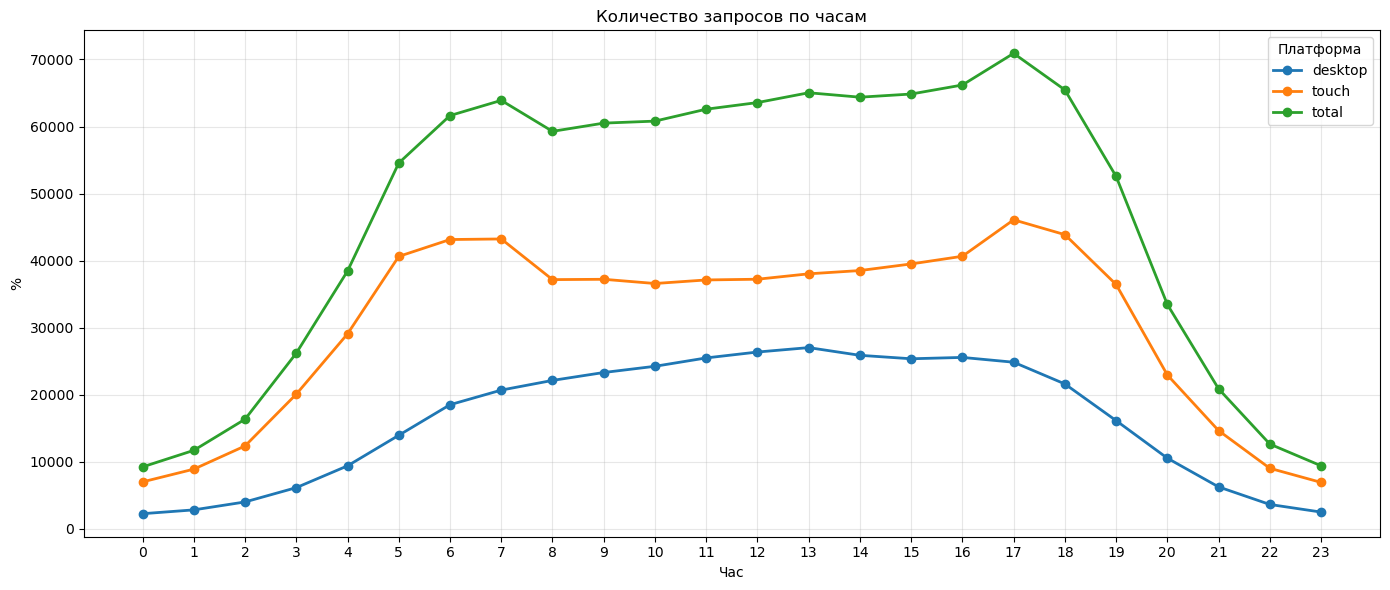

In [14]:
df_hour_pivot.plot(kind='line', marker='o', figsize=(14, 6), linewidth=2)
plt.title('Количество запросов по часам')
plt.xlabel('Час')
plt.ylabel('%')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(title='Платформа')
plt.tight_layout()
plt.show()


In [15]:
df_hour_norm = df_hour_pivot.div(df_hour_pivot.sum()) * 100
df_hour_norm

hour,desktop,touch,total
0,0.575382,0.961436,0.826928
1,0.722447,1.223108,1.048669
2,1.027394,1.699901,1.465588
3,1.576762,2.763527,2.350038
4,2.414594,4.002611,3.449319
5,3.588280,5.594263,4.895344
6,4.763254,5.941047,5.530683
7,5.324728,5.952891,5.734028
8,5.697155,5.117332,5.319352
9,6.000814,5.124081,5.429550


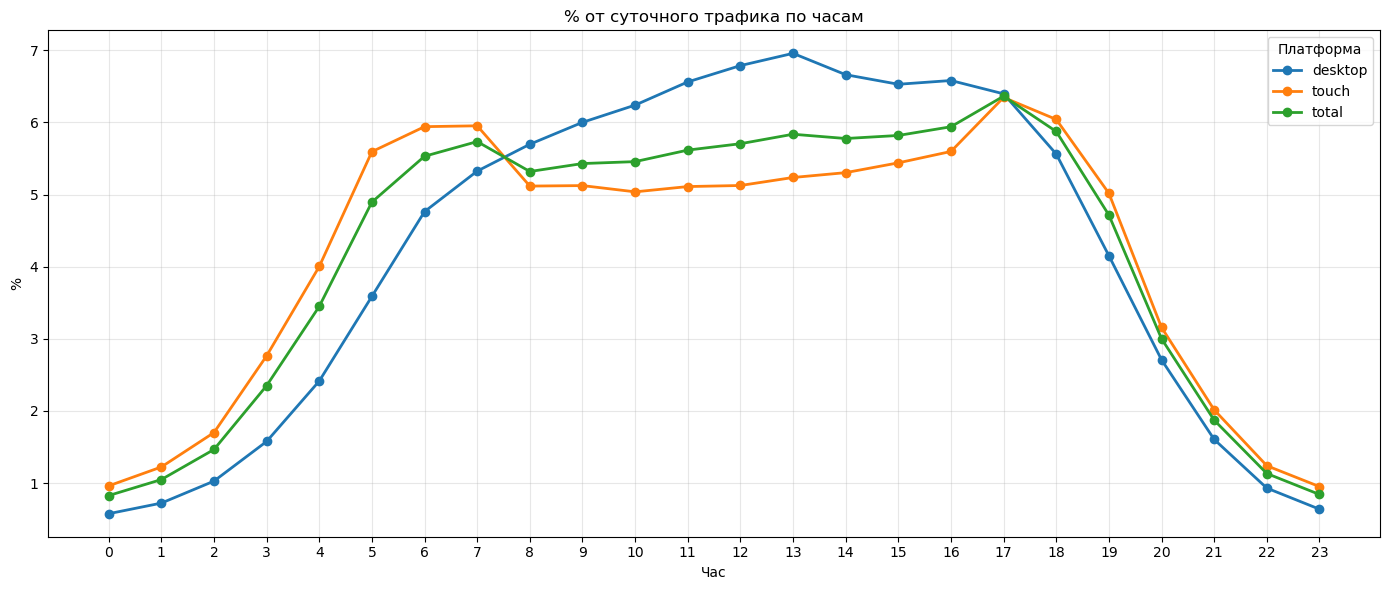

In [16]:

df_hour_norm.plot(kind='line', marker='o', figsize=(14, 6), linewidth=2)
plt.title('% от суточного трафика по часам')
plt.xlabel('Час')
plt.ylabel('%')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(title='Платформа')
plt.tight_layout()
plt.show()

##### Данные по будням и выходным

In [17]:
df['is_weekend'] = df['datetime'].dt.dayofweek >= 5
df['day_type'] = df['is_weekend'].map({False: 'будни', True: 'выходные'})

hour_share = df.groupby(['day_type', 'hour']).size().unstack(0)
hour_share_pct = hour_share.div(hour_share.sum()) * 100

hour_share_pct

day_type,будни,выходные
hour,,
0,0.828555,0.822343
1,1.099553,0.905263
2,1.554863,1.213984
3,2.539647,1.815665
4,3.716037,2.697628
5,5.166222,4.131931
6,5.694114,5.070088
7,5.721226,5.770107
8,5.260080,5.486399


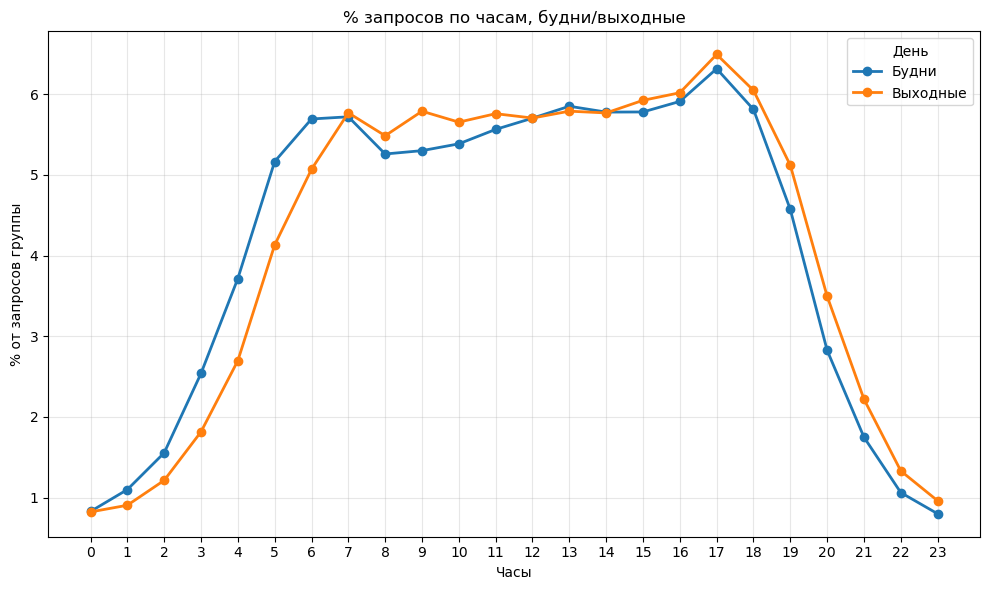

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(hour_share_pct.index, hour_share_pct['будни'], marker='o', linewidth=2, label='Будни')
ax.plot(hour_share_pct.index, hour_share_pct['выходные'], marker='o', linewidth=2, label='Выходные')
ax.set_title('% запросов по часам, будни/выходные')
ax.set_xlabel('Часы')
ax.set_ylabel('% от запросов группы')
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
ax.legend(title='День')

plt.tight_layout()
plt.show()

In [19]:
hour_platform = df.groupby(['day_type', 'platform', 'hour']).size().unstack(['day_type', 'platform'])
hour_platform_pct = hour_platform.div(hour_platform.sum()) * 100
hour_platform_pct.columns = [f'{d}_{p}' for d, p in hour_platform_pct.columns]

hour_platform_pct

,будни_desktop,будни_touch,выходные_desktop,выходные_touch
hour,,,,
0,0.573870,0.971124,0.580177,0.935736
1,0.753077,1.293505,0.625302,1.036353
2,1.099973,1.809503,0.797207,1.409138
3,1.673504,3.024499,1.269944,2.071196
4,2.581397,4.351190,1.885576,3.077867
5,3.816538,5.921753,2.864357,4.725467
6,5.034740,6.063221,3.902229,5.616932
7,5.431097,5.883636,4.987376,6.136617
8,5.690253,5.019276,5.719044,5.377464


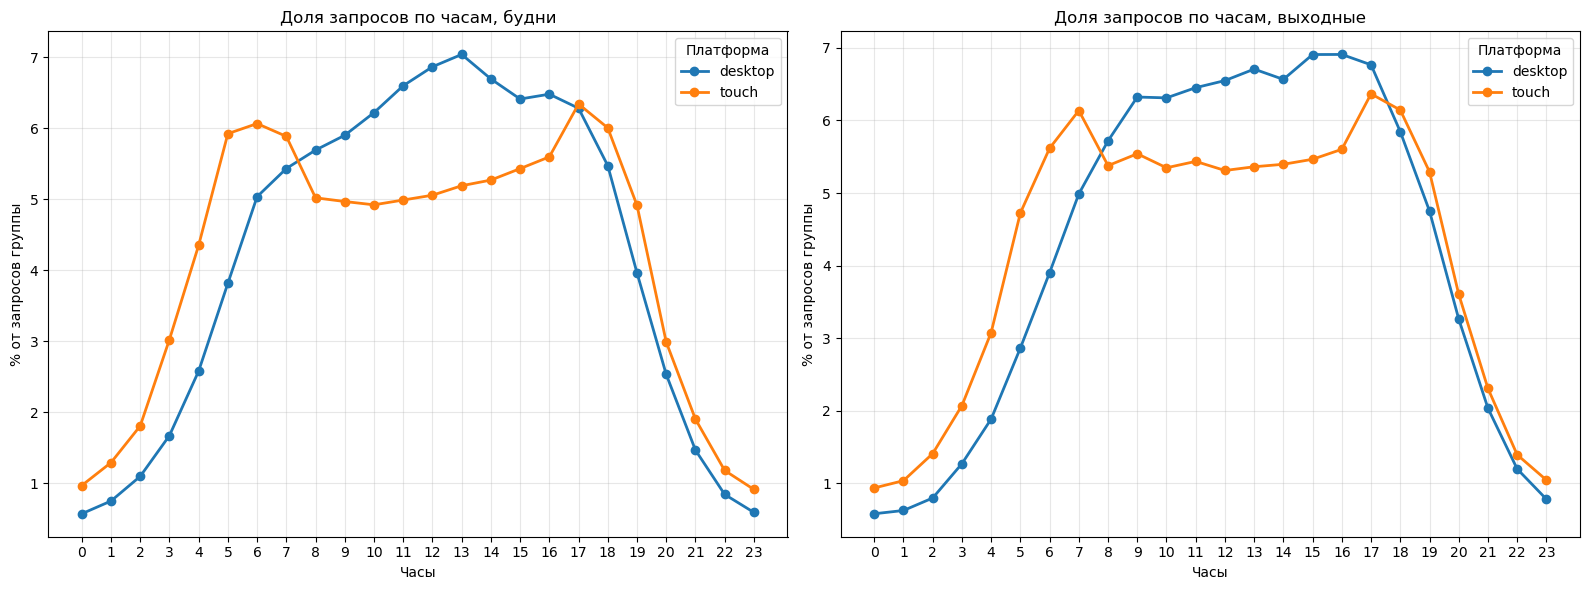

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, day in zip(axes, ['будни', 'выходные']):
    ax.plot(hour_share_pct.index, hour_platform_pct[f'{day}_desktop'],
            marker='o', linewidth=2, label='desktop')
    ax.plot(hour_share_pct.index, hour_platform_pct[f'{day}_touch'],
            marker='o', linewidth=2, label='touch')
    ax.set_title(f'Доля запросов по часам, {day}')
    ax.set_xlabel('Часы')
    ax.set_ylabel('% от запросов группы')
    ax.set_xticks(range(0, 24))
    ax.grid(True, alpha=0.3)
    ax.legend(title='Платформа')

plt.tight_layout()
plt.show()

### Выводы
**Desktop**
Компьютер - устройство для работы/учебы, показывает пик/плато в рабочее время после чего происходит резкий спад

**Touch**
Мобильное устройтво всегде под рукой, есть два пика - утром и вечером, что можно сопоставить с поездками на работу/учебу и дорогу домой

P.S. В данных скорее всего не учитывается часовой пояс и время в UTC

P.P.S Чтобы утвердится или опровергнуть предположение, надо посмотреть дополнительно тематики запросов по часам

## 5. Тематики запросов

In [21]:
df['query_clean'] = df['query'].str.lower().str.strip()

df_clean = df[df['query_clean'] != ''].copy()

unique_queries = pd.Series(df['query_clean'].unique())



In [22]:
unique_queries.head()

0         малевич картины
1              психология
2    с днём рождения лена
3       зверополис фильмы
4      алабай собака фото
dtype: object

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
import hdbscan
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

STOP_WORDS_RU = ['и','в','на','с','для','по','не','как','это','что','из','от','а','но','за','у','к','о','же','бы',
                 'его','её','их','при','до','или','то','все','он','она','они','мы','вы','ты','я','так','ещё','уже',
                 'фото','картинки','обои','скачать','найти','смотреть']

embedding_model = SentenceTransformer("intfloat/multilingual-e5-small")

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric="cosine", random_state=42)
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=50, metric="euclidean",
                                cluster_selection_method="eom", prediction_data=True)

topic_model = BERTopic(
    embedding_model=embedding_model,
    language="multilingual",
    calculate_probabilities=False,   
    nr_topics=50,                    
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=CountVectorizer(  
        ngram_range=(1, 2), stop_words=STOP_WORDS_RU,
    ),
)




topics, probs = topic_model.fit_transform(unique_queries)


topics = topic_model.reduce_outliers(unique_queries, topics, strategy="c-tf-idf")
topic_model.update_topics(unique_queries, topics=topics)

topic_info = topic_model.get_topic_info()



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-08-02 01:16:27,267 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [24]:
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4303,-1_это_фото_самсунг_ваз,"[это, фото, самсунг, ваз, буква, закон, как, б...","[путешествия рик и морти, музыка бесконечное л..."
1,0,12851,0_мода_история_музыка_игры,"[мода, история, музыка, игры, спорт, наука, те...","[спорт обои, образование смотреть, наука фото]"
2,1,1886,1_рождения_днём_днем_женщине,"[рождения, днём, днем, женщине, открытки, позд...","[картинки с днём рождения женщине, с днём рожд..."
3,2,928,2_животные_собака_кошка_кот,"[животные, собака, кошка, кот, смешарики, соба...","[картинки животные, животные картинки, скачать..."
4,3,624,3_погода_неделю_10_на,"[погода, неделю, 10, на, дней, сочи, москве, 1...","[погода в, картинки погода, погода скачать]"
5,4,771,4_алфавит_такое_разбор_что,"[алфавит, такое, разбор, что, таблица, слова, ...","[английский алфавит картинки, английский алфав..."
6,5,660,5_карта_карте_метро_россии,"[карта, карте, метро, россии, схема, москва, м...","[карта метро москвы 2021, карта метро москвы, ..."
7,6,297,6_старс_бравл_браво_brawl,"[старс, бравл, браво, brawl, stars, бразерс, с...","[картинки браво старс, браво старс, бравл старс]"
8,7,405,7_большие_красивая_короткое_самые,"[большие, красивая, короткое, самые, большая, ...","[игры красивая короткое гол, наука красивая ко..."
9,8,350,8_обои_телефон_стол_рабочий,"[обои, телефон, стол, рабочий, на, яндекс, эст...","[скачать картинки на телефон, картинки на теле..."


In [25]:
CURATED_TOPICS = {
    "Поздравления": ["с днём рождения", "доброе утро", "спокойной ночи", "с 1 сентября",
                     "поздравление", "открытки", "с днём свадьбы"],
    "Учёба ": ["гдз", "алфавит", "английский алфавит", "разбор слова", "задание",
                    "русскому языку", "литература", "таблица умножения", "иностранный язык"],
    "Животные": ["собака", "кошка", "кот", "щенок", "животные", "домашнее животное"],
    "Погода": ["погода", "прогноз", "погода на неделю", "дождь"],
    "Игры": ["бравл старс", "геншин", "майнкрафт", "роблокс", "undertale",
             "токийские мстители", "цунаде", "компьютерные игры"],
    "Поп-культура": ["гарри поттер", "леди баг", "мстители", "аниме", "боруто",
                    "амонг ас", "tsunade", "цунаде", "ankha", "тян", "гравити фолз"],
    "Фильмы и сериалы": ["фильм", "сериал", "мультик", "кино"],
    "Кулинария": ["рецепт", "кухня", "кулинария", "еда", "готовка", "блюдо"],
    "Путешествия": ["путешествия", "отпуск", "отдых", "туризм"],
    "Карты и метро": ["карта метро", "схема метро", "карта россии", "карта мира", "карта"],
    "Техника и смартфоны": ["айфон", "iphone", "самсунг", "samsung", "ноутбук",
                            "планшет", "смартфон", "гаджет"],
    "Мода и маникюр": ["маникюр", "ногти", "мода", "дизайн ногтей"],
    "Тату": ["тату", "эскизы тату", "татуировки"],
    "Новости и политика": ["новости", "выборы", "госдума"],
    "NSFW / 18+": ["18+", "без цензуры", "зрелые женщины", "нижнее белье",
                   "bokep", "эротика"],
    "Азартные игры": ["казино", "казино онлайн", "покер", "покердом", "poker"],
    "Обои и фоны": ["обои", "однотонный фон", "фон для фото", "рабочий стол",
                    "красивый фон", "фон"],
    "Музыка": ["музыка", "песня", "клип", "исполнитель", "текст песни"],
    "Спорт": ["спорт", "футбол", "тренировка", "спортсмен", "стадион", "хоккей"],
    "Наука и технологии": ["наука", "технологии", "история", "биология",
                           "астрономия", "таблица менделеева"],
    "Здоровье и психология": ["психология", "здоровье", "психотерапия", "стресс",
                              "мотивация", "медитация"],
    "Календарь": ["календарь", "производственный календарь", "календарь 2021", "праздники"],
    "Перевод и языки": ["переводчик", "перевод", "английский", "иностранные языки"],
    "Знаменитости": ["актрисы", "полина гагарина", "ева элфи", "моргенштерн", "звезды"],
    "Авто": ["бмв", "bmw", "машина", "автомобиль", "машина", "авто", "автопром"],
    "Прочее": [],  
}




In [26]:
touch_top = df[df['platform'] == 'touch']['query'].value_counts().head(50)
desktop_top = df[df['platform'] == 'desktop']['query'].value_counts().head(50)

result = pd.DataFrame({
    'touch_cnt': touch_top.values,
    'touch_query': touch_top.index,
    'desktop_cnt': desktop_top.values,
    'desktop_query': desktop_top.index,
})
result

,touch_cnt,touch_query,desktop_cnt,desktop_query
0,4903,с днём рождения женщине,2804,календарь 2021
1,3967,с днём рождения,2631,таблица менделеева
2,3623,с днём рождения мужчине,1647,картинки
3,3005,с днем рождения,1293,английский алфавит
4,2840,погода,1143,обои на рабочий стол
5,2833,игры,1116,Одноклассники (социальная сеть)
6,2746,фильмы,877,таблица квадратов
7,2708,новости,874,алфавит
8,2696,музыка,867,таблица умножения
9,2648,мода,795,карта мира


In [27]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("intfloat/multilingual-e5-small")

cat_names = [c for c in CURATED_TOPICS if c != 'Прочее']
cat_exemplars = [CURATED_TOPICS[c] for c in cat_names]
splits = np.cumsum([0] + [len(lst) for lst in cat_exemplars])

ex_emb = embedding_model.encode([e for lst in cat_exemplars for e in lst], batch_size=64)
centroids = np.array([ex_emb[splits[i]:splits[i + 1]].mean(axis=0)
                      for i in range(len(cat_names))])
centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)

q_emb = embedding_model.encode(unique_queries.tolist(), batch_size=64, show_progress_bar=True)
q_emb = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)

scores = q_emb @ centroids.T
best_idx = scores.argmax(axis=1)
best_score = scores[np.arange(len(scores)), best_idx]




Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/470 [00:00<?, ?it/s]

In [28]:
SIM_THRESHOLD = 0.87
for i in (0.86, 0.87, 0.88):
    print(f'Порог {i}: Прочее = {(best_score < i).mean()*100:.1f}%')
labels = np.where(best_score >= SIM_THRESHOLD, [cat_names[i] for i in best_idx], 'Прочее')

Порог 0.86: Прочее = 1.7%
Порог 0.87: Прочее = 3.8%
Порог 0.88: Прочее = 8.6%


In [29]:
manual_map = pd.DataFrame({'query_clean': unique_queries.values,
                           'topic_name': labels,
                           'topic_score': best_score})
manual_map['topic_id'] = manual_map['topic_name'].map(
    {n: i + 1 for i, n in enumerate(cat_names)}).fillna(0).astype(int)

df = df.merge(manual_map, on='query_clean', how='left')

manual_map

,query_clean,topic_name,topic_score,topic_id
0,малевич картины,Знаменитости,0.903937,24
1,психология,Здоровье и психология,0.963800,21
2,с днём рождения лена,Поздравления,0.909893,1
3,зверополис фильмы,Фильмы и сериалы,0.893286,7
4,алабай собака фото,Животные,0.887011,3
...,...,...,...,...
30028,винкс фильмы,Фильмы и сериалы,0.893275,7
30029,nagatoro технологии,Игры,0.922087,5
30030,мода негры,NSFW / 18+,0.914098,15
30031,психология с негром,Здоровье и психология,0.903468,21


In [30]:
print(f'Уверенность (topic_score): p10={np.percentile(best_score, 10):.2f} '
      f'p50={np.percentile(best_score, 50):.2f} p90={np.percentile(best_score, 90):.2f}')

print(f'Доля «Прочее»: {(df["topic_name"] == "Прочее").mean()*100:.1f}% строк')

df.groupby('topic_name')['query_clean'].nunique().sort_values(ascending=False)

Уверенность (topic_score): p10=0.88 p50=0.91 p90=0.93
Доля «Прочее»: 2.9% строк


topic_name
Поп-культура             6058
Учёба                    2975
Поздравления             2829
Игры                     2519
NSFW / 18+               1866
Знаменитости             1623
Наука и технологии       1469
Здоровье и психология    1268
Прочее                   1133
Животные                  949
Обои и фоны               923
Погода                    797
Фильмы и сериалы          755
Кулинария                 745
Спорт                     626
Музыка                    577
Путешествия               534
Мода и маникюр            507
Карты и метро             487
Новости и политика        402
Техника и смартфоны       305
Авто                      275
Календарь                 198
Тату                       75
Перевод и языки            70
Азартные игры              68
Name: query_clean, dtype: int64

In [31]:
cross = df.groupby(['platform', 'topic_name']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

cross_pct.T

platform,desktop,touch
topic_name,,
NSFW / 18+,4.680321,5.180684
Авто,1.057270,0.943808
Азартные игры,0.123112,0.482991
Животные,2.219366,2.140336
Здоровье и психология,1.578308,2.264974
Знаменитости,5.646158,5.002748
Игры,7.357365,5.399111
Календарь,2.849092,1.192809
Карты и метро,3.294923,3.075330


In [32]:
diff = (cross_pct.loc['touch'] - cross_pct.loc['desktop']).sort_values()
diff

topic_name
Учёба                    -5.624552
Поп-культура             -3.748866
Обои и фоны              -2.819506
Игры                     -1.958254
Календарь                -1.656283
Наука и технологии       -0.905408
Знаменитости             -0.643411
Прочее                   -0.576188
Карты и метро            -0.219593
Авто                     -0.113462
Животные                 -0.079030
Техника и смартфоны      -0.063345
Перевод и языки           0.090392
Тату                      0.115946
Музыка                    0.200922
Новости и политика        0.220522
Погода                    0.294399
Путешествия               0.341142
Азартные игры             0.359879
Кулинария                 0.431921
Спорт                     0.475600
NSFW / 18+                0.500364
Фильмы и сериалы          0.599574
Здоровье и психология     0.686667
Мода и маникюр            1.449508
Поздравления             12.641062
dtype: float64

In [33]:
import os
df.to_csv(os.path.join(os.getcwd(), 'dataset_with_topics.csv'), index=False, encoding='utf-8')


### Выводы 
1. Поздравления(дельта = 12.6% для touch) - показывает социальный сценарий, так как поздравляют обычно в мессенджирах на смартфонах
2. Учеба(дельта = 5.6% для desktop) - обучение обычно происходит за компьютером
3. Поп-культура(дельта = 3.7% для desktop) + Игры - объясняется геймингом на ПК и просмотром контента на большом экране
